# 2018 Fannie Mae SF Loan Analysis

# Imports and Data Cleaning

In [410]:
from statistics import LinearRegression

# Regular imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")


In [411]:
df = pd.read_csv('./data/fnma_sf2018d_loans.txt', sep=r'\s+', index_col=False, header=None)

In [412]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1,1,2,2,2,1,2,1,4,1,102000,2,2,2,1,0.0
1,1,2,3,2,3,2,2,1,2,1,425000,4,3,3,1,0.0
2,1,3,3,2,2,5,1,1,3,1,220000,4,1,1,1,0.0
3,1,4,3,2,2,5,1,1,4,1,233000,3,1,1,1,0.0
4,1,5,3,1,2,5,1,1,3,1,195000,3,1,1,1,0.0


Since there are no column names, we'll add them using the information from the pdf

In [413]:
column_names = ["Enterprise Flag", "Record Number", "2010 Census Tract - Percent Minority", "Tract Income Ratio", "Borrower Income Ratio", "LTV Ratio", "Purpose of Loan", "Federal Guarantee", "Credit Score", "Product Type", "Purchase Price", "Interest Rate at Origination", "Term of Mortgage at Origination", "Amortization Term", "Portfolio Flag", "Percent Repurchased"]

In [414]:
df.columns = column_names

In [415]:
df.head()

,Enterprise Flag,Record Number,2010 Census Tract - Percent Minority,Tract Income Ratio,Borrower Income Ratio,LTV Ratio,Purpose of Loan,Federal Guarantee,Credit Score,Product Type,Purchase Price,Interest Rate at Origination,Term of Mortgage at Origination,Amortization Term,Portfolio Flag,Percent Repurchased
0,1,1,2,2,2,1,2,1,4,1,102000,2,2,2,1,0.0
1,1,2,3,2,3,2,2,1,2,1,425000,4,3,3,1,0.0
2,1,3,3,2,2,5,1,1,3,1,220000,4,1,1,1,0.0
3,1,4,3,2,2,5,1,1,4,1,233000,3,1,1,1,0.0
4,1,5,3,1,2,5,1,1,3,1,195000,3,1,1,1,0.0


Some basic stats:

In [416]:
df.describe()

,Enterprise Flag,Record Number,2010 Census Tract - Percent Minority,Tract Income Ratio,Borrower Income Ratio,LTV Ratio,Purpose of Loan,Federal Guarantee,Credit Score,Product Type,Purchase Price,Interest Rate at Origination,Term of Mortgage at Origination,Amortization Term,Portfolio Flag,Percent Repurchased
count,83836.0,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,8.383600e+04,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000
mean,1.0,41918.500000,2.347297,1.953421,2.533267,3.421764,1.237320,1.000072,3.322523,1.001622,2.222880e+05,4.300301,1.168865,1.168865,1.089771,0.047002
std,0.0,24201.512921,0.746548,0.754076,0.798715,1.372592,0.425443,0.008460,1.040816,0.040244,1.502645e+05,1.153851,0.505193,0.505193,0.285854,0.196696
min,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.400000e+04,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.0,20959.750000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.230000e+05,4.000000,1.000000,1.000000,1.000000,0.000000
50%,1.0,41918.500000,3.000000,2.000000,3.000000,4.000000,1.000000,1.000000,3.000000,1.000000,1.850000e+05,4.000000,1.000000,1.000000,1.000000,0.000000
75%,1.0,62877.250000,3.000000,2.000000,3.000000,5.000000,1.000000,1.000000,4.000000,1.000000,2.820000e+05,5.000000,1.000000,1.000000,1.000000,0.000000
max,1.0,83836.000000,9.000000,9.000000,9.000000,5.000000,2.000000,2.000000,9.000000,2.000000,3.955000e+06,7.000000,3.000000,3.000000,2.000000,1.000000


In [417]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83836 entries, 0 to 83835
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Enterprise Flag                       83836 non-null  int64  
 1   Record Number                         83836 non-null  int64  
 2   2010 Census Tract - Percent Minority  83836 non-null  int64  
 3   Tract Income Ratio                    83836 non-null  int64  
 4   Borrower Income Ratio                 83836 non-null  int64  
 5   LTV Ratio                             83836 non-null  int64  
 6   Purpose of Loan                       83836 non-null  int64  
 7   Federal Guarantee                     83836 non-null  int64  
 8   Credit Score                          83836 non-null  int64  
 9   Product Type                          83836 non-null  int64  
 10  Purchase Price                        83836 non-null  int64  
 11  Interest Rate at Originati

Next I want to remove any rows that have data that is either missing or not available

In [418]:
df = df[(df["2010 Census Tract - Percent Minority"] != 9)
        & (df["Tract Income Ratio"] != 9)
        & (df["LTV Ratio"] != 9)
        & (df["Credit Score"] != 9)
        & (df["Product Type"] != 9)
        & (df["Purchase Price"] != 999999999)
        & (df["Interest Rate at Origination"] != 99)
        & (df["Term of Mortgage at Origination"] != 9)
        & (df["Amortization Term"] != 9)
        & (df["Percent Repurchased"] != 9999.0)]

In [419]:
df.count() #Looks like the above removed 164 columns

Enterprise Flag                         83672
Record Number                           83672
2010 Census Tract - Percent Minority    83672
Tract Income Ratio                      83672
Borrower Income Ratio                   83672
LTV Ratio                               83672
Purpose of Loan                         83672
Federal Guarantee                       83672
Credit Score                            83672
Product Type                            83672
Purchase Price                          83672
Interest Rate at Origination            83672
Term of Mortgage at Origination         83672
Amortization Term                       83672
Portfolio Flag                          83672
Percent Repurchased                     83672
dtype: int64

In [420]:
#Dropping the Enterprise Flag Column since this is all Fannie Mae data
df.drop(labels="Enterprise Flag", axis=1, inplace=True)

In [421]:
df.head()

,Record Number,2010 Census Tract - Percent Minority,Tract Income Ratio,Borrower Income Ratio,LTV Ratio,Purpose of Loan,Federal Guarantee,Credit Score,Product Type,Purchase Price,Interest Rate at Origination,Term of Mortgage at Origination,Amortization Term,Portfolio Flag,Percent Repurchased
0,1,2,2,2,1,2,1,4,1,102000,2,2,2,1,0.0
1,2,3,2,3,2,2,1,2,1,425000,4,3,3,1,0.0
2,3,3,2,2,5,1,1,3,1,220000,4,1,1,1,0.0
3,4,3,2,2,5,1,1,4,1,233000,3,1,1,1,0.0
4,5,3,1,2,5,1,1,3,1,195000,3,1,1,1,0.0


In [422]:
#Changing Purpose of Loan column to a categorical variable rather than numeric
df["Purpose of Loan"] = df["Purpose of Loan"].replace({
    1: "Home Purchase",
    2: "Refinance/Other"
})

# Exploratory Data Analysis

We saw that the mean purchase price in our describe method was about $222,000 - so lets look at the distribution of the purchase price

Text(0.5, 1.0, 'Density of Purchase Price')

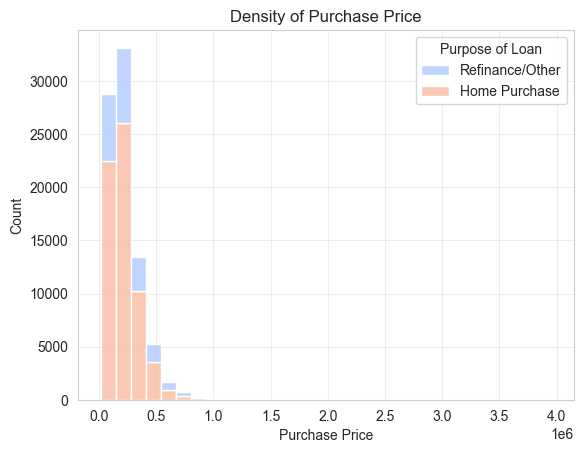

In [423]:
sns.histplot(df, x="Purchase Price", hue="Purpose of Loan", palette="coolwarm", bins=30, multiple = "stack")
plt.title("Density of Purchase Price")

So we see here that despite the average being 222,000. The majority of our loans in the dataset are around 50,000 or below. Let's examine this further:

Text(0.5, 1.0, 'Density of Purchase Price - Violin Plot')

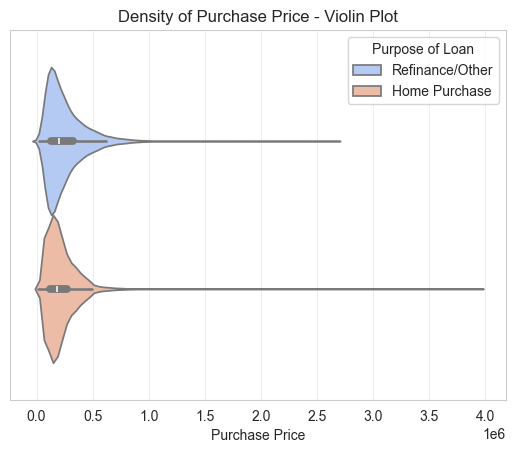

In [424]:
sns.violinplot(df, x="Purchase Price", hue="Purpose of Loan", palette="coolwarm")
plt.title("Density of Purchase Price - Violin Plot")

So we see here that despite the bulk of our loans being below 50,000 there are several outliers bringing the average up. Now lets take a look at Purchase vs Refinance amounts:

Text(0.5, 1.0, 'Count of Purpose of Loan Types')

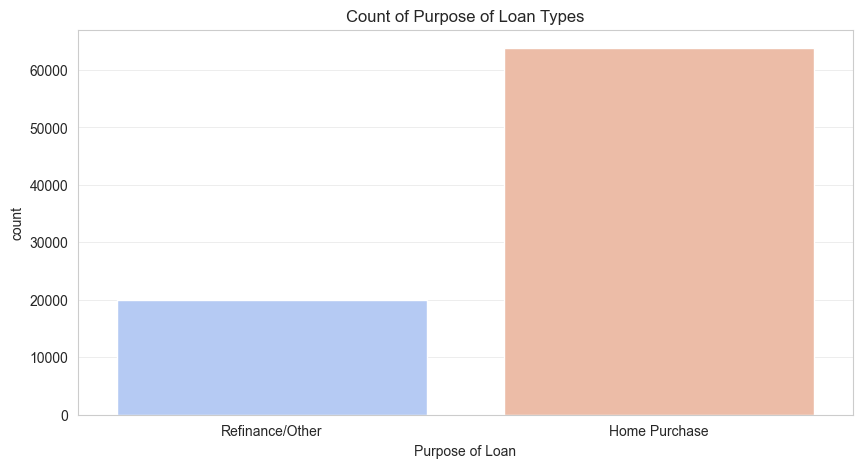

In [425]:
# Purchase vs Refinance

plt.figure(figsize=(10, 5))

ax = sns.countplot(df, x="Purpose of Loan", hue="Purpose of Loan", palette="coolwarm")
plt.title("Count of Purpose of Loan Types")


So we see here that the number of Home Purchases is about 3x that of refinances for this loan set. So now we'll take a look at a few specific attributes in relation to price:

([<matplotlib.axis.XTick at 0x1af1dbc1950>,
 [Text(0, 0, '<620'),
  Text(1, 0, '620-659'),
  Text(2, 0, '660-699'),
  Text(3, 0, '700-760'),
  Text(4, 0, '>760')])

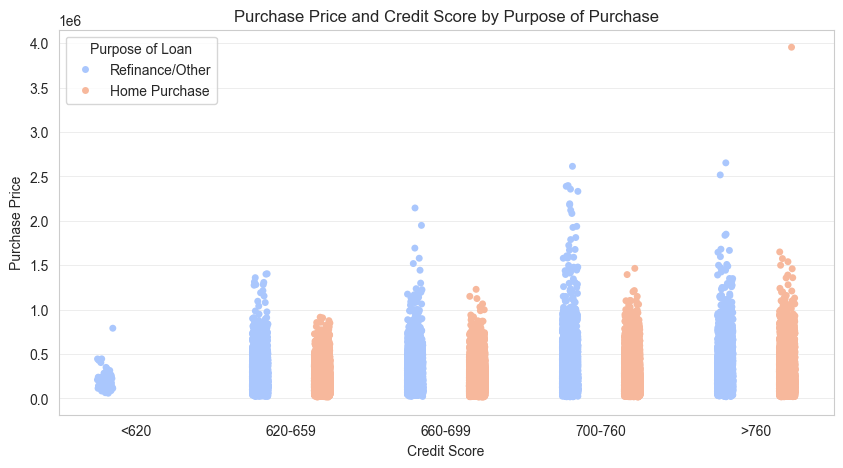

In [426]:
#Credit Score vs Purchase Price in relation to Purpose of the Loan

plt.figure(figsize=(10, 5))

ax = sns.stripplot(
    data=df,
    x="Credit Score",
    y="Purchase Price",
    hue="Purpose of Loan",
    palette="coolwarm",
    jitter=True,
    dodge=True
)

plt.title("Purchase Price and Credit Score by Purpose of Purchase")
plt.xticks(np.arange(5), ["<620", "620-659", "660-699", "700-760", ">760"])


([<matplotlib.axis.XTick at 0x1af4fedd6d0>,
 [Text(0, 0, '0, <=60% '),
  Text(1, 0, '60, <=80%'),
  Text(2, 0, '80, <=90%'),
  Text(3, 0, '90, <=95% '),
  Text(4, 0, '>95%')])

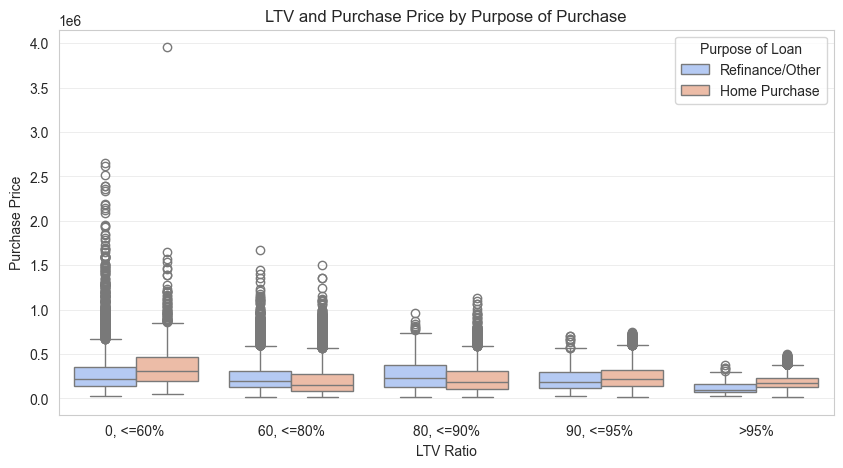

In [427]:
plt.figure(figsize=(10, 5))

sns.boxplot(data = df, x="LTV Ratio", y="Purchase Price", hue="Purpose of Loan", palette="coolwarm")

plt.title("LTV and Purchase Price by Purpose of Purchase")
plt.xticks(np.arange(5),["0, <=60% ", "60, <=80%", "80, <=90%", "90, <=95% ", ">95%"])

([<matplotlib.axis.XTick at 0x1af376411d0>,
 [Text(0, 0, '<4'),
  Text(1, 0, '4.00-<4.50'),
  Text(2, 0, '4.50-<5.00'),
  Text(3, 0, '5.00-<5.50'),
  Text(4, 0, '5.50-< 6.00'),
  Text(5, 0, '6.00-<6.50'),
  Text(6, 0, '6.50-<7.00'),
  Text(7, 0, '7.00-<7.50'),
  Text(8, 0, '7.50 - < 8.00'),
  Text(9, 0, '>=8')])

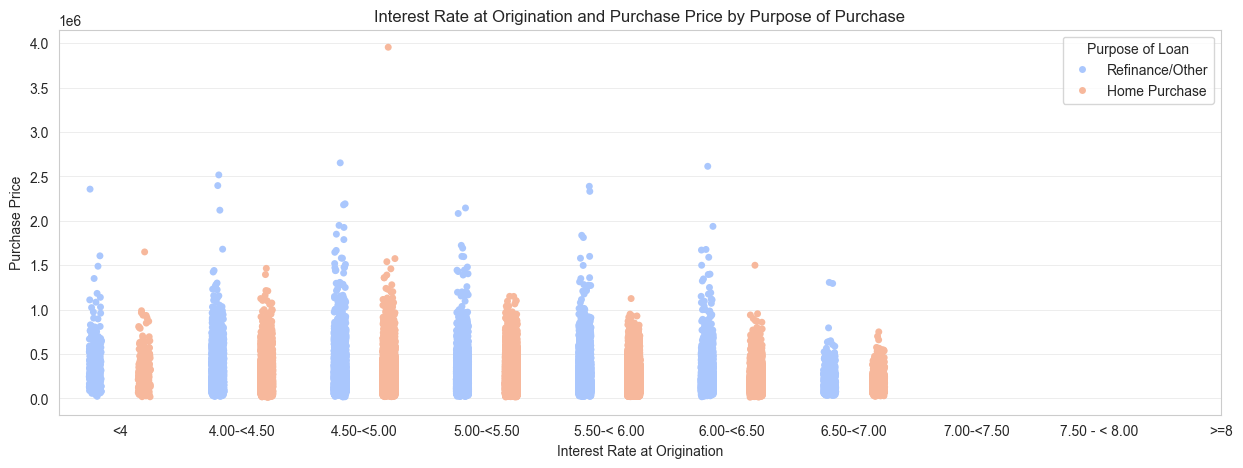

In [428]:
plt.figure(figsize=(15, 5))

ax = sns.stripplot(
    data=df,
    x="Interest Rate at Origination",
    y="Purchase Price",
    hue="Purpose of Loan",
    palette="coolwarm",
    jitter=True,
    dodge=True
)

plt.title("Interest Rate at Origination and Purchase Price by Purpose of Purchase")
plt.xticks(np.arange(10),["<4", "4.00-<4.50", "4.50-<5.00", "5.00-<5.50", "5.50-< 6.00", "6.00-<6.50", "6.50-<7.00", "7.00-<7.50", "7.50 - < 8.00", ">=8"])

In [429]:
df["Interest Rate at Origination"].value_counts()

Interest Rate at Origination
5    27391
4    25519
3    13376
6    10103
2     5561
7     1193
1      529
Name: count, dtype: int64

([<matplotlib.axis.XTick at 0x1aeaef45450>,
 [Text(0, 0, '>=0, <=50% '),
  Text(1, 0, '>50, <=80%'),
  Text(2, 0, '>80%'),
  Text(3, 0, 'N/A')])

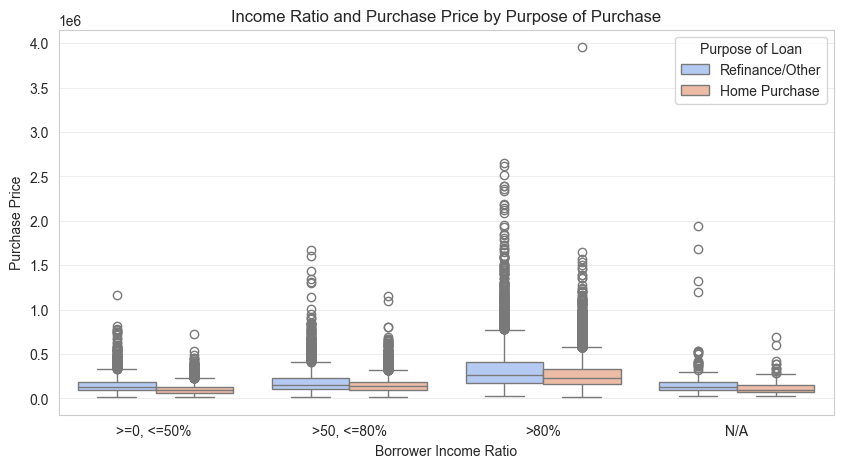

In [432]:
plt.figure(figsize=(10, 5))

sns.boxplot(data = df, x="Borrower Income Ratio", y="Purchase Price", hue="Purpose of Loan", palette="coolwarm")

plt.title("Income Ratio and Purchase Price by Purpose of Purchase")
plt.xticks(np.arange(4),[">=0, <=50% ", ">50, <=80%", ">80%", "N/A"])

In [431]:
df["Borrower Income Ratio"].value_counts()

Borrower Income Ratio
3    50151
2    24943
1     8197
9      381
Name: count, dtype: int64

So now we have a bit more insight into what our data looks like. Now we'll try developing a Linear Regression model based on the data!

# Training a Linear Regression Model

In [ ]:
#Changing Purpose of Loan column back to numeric
df["Purpose of Loan"] = df["Purpose of Loan"].replace({
    "Home Purchase": 1,
    "Refinance/Other": 2
})

In [ ]:
X = df[['Borrower Income Ratio', 'LTV Ratio', 'Credit Score', 'Interest Rate at Origination']]
y = df["Purchase Price"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lm = LinearRegression()

In [ ]:
lm.fit(X_train, y_train)

In [433]:
print(lm.intercept_)

190544.5158457841


In [435]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

                               Coefficient
Borrower Income Ratio         59327.921155
LTV Ratio                    -17207.028490
Credit Score                   4826.600506
Interest Rate at Origination -17555.713523


So what does this mean? It's hard to say because all the values are categorical representing a particular range (see PDF for details). This would probably be more useful of a model if we had the actual values for each user. However, we can see that holding all features fixed:
- A 1 unit increase in Borrower Income Ratio or Credit Score have an increase in purchase price
- A 1 unit increase in LTV and Interest Rate at Origination have a decrease in purchase price

In other words, Borrower Income Ratio or Credit Score is proportional to purchase price whereas LTV and Interest Rate at Origination are inversely proportional to purchase price

# Evaluating our Model

In [ ]:
predictions = lm.predict(X_test)

In [ ]:
from sklearn import metrics

In [ ]:
print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("MSE:", metrics.mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

These are loss functions (want to minimize them). Again not super useful but mostly for fun
- Mean Absolute Error (MAE) - is the mean of the absolute value of the errors
- Mean Squared Error (MSE) - is the mean of the squared errors
- Root Mean Squared Error (RMSE) - is the square root of the mean of the squared errors